In [1]:
%matplotlib inline

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV

from sklearn.linear_model import RidgeClassifierCV
from sklearn.linear_model import LinearRegression

from ultralytics import YOLO
from PIL import Image

import matplotlib.pyplot as plt
import mediapipe as mp
import cv2
import time
import numpy as np
import pandas as pd
import os

import warnings
warnings.filterwarnings('ignore')

,classifier,feature_importances,Train Accuracy,Train Precision,Train Recall,Train F1,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
Случайный лес,Случайный лес,None,1.000000,1.000000,1.000000,1.000000,0.725389,0.740566,0.725389,0.724668
Метод опорных векторов,Метод опорных векторов,None,0.810390,0.818511,0.810390,0.811288,0.704663,0.726135,0.704663,0.706112
K-ближайших соседей,K-ближайших соседей,None,0.774026,0.775018,0.774026,0.772173,0.704663,0.716330,0.704663,0.702108


Размеры выборок:
Обучающая выборка: (770, 8)
Валидационная выборка: (193, 8)

Оптимизация Случайный лес...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Лучшие параметры для Случайный лес:
clf__max_depth: 10
clf__min_samples_leaf: 2
clf__min_samples_split: 2
clf__n_estimators: 100
poly__degree: 2

Лучший результат на обучающей выборке: 0.7325
Результат на валидационной выборке: 0.7047
Размеры выборок:
Обучающая выборка: (770, 8)
Валидационная выборка: (193, 8)

Оптимизация Метод опорных векторов...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Лучшие параметры для Метод опорных векторов:
clf__C: 10
clf__gamma: auto
clf__kernel: rbf
poly__degree: 2
scaler: StandardScaler()

Лучший результат на обучающей выборке: 0.7065
Результат на валидационной выборке: 0.7098
Размеры выборок:
Обучающая выборка: (770, 8)
Валидационная выборка: (193, 8)

Оптимизация K-ближайших соседей...
Fitting 5 folds for each of 240 candidates, totalling 1200 fits

Лучшие параметры 

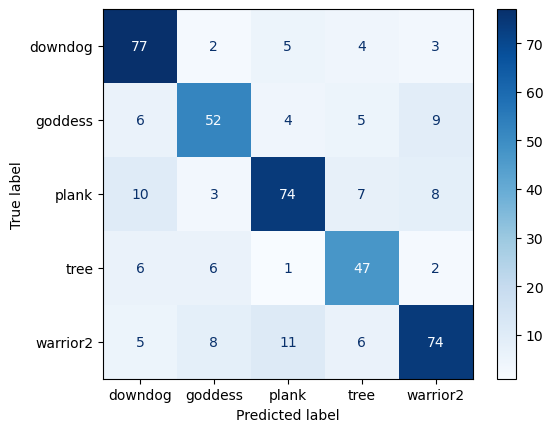

In [524]:
# Выбор оптимальной архитектуры
X_best_dataset_train, X_best_dataset_test, best_model, best_name_model, best_param = Grid_Search_CV('mediapipe_angle',  X_angle, Y_angle, X_test_angle, 3)

# Обучение оптимального классификатора на всем обучающем наборе и оценка его качества    
print_result(X_best_dataset_train, Y_angle, X_best_dataset_test, Y_test_angle, best_model, best_name_model, best_param)

Размеры выборок:
Обучающая: 770 примеров
Валидационная: 193 примеров

Обучение Логистическая регрессия...
LogisticRegression(random_state=42)

Метрики качества:
Точность (Accuracy) на обучении: 0.7948
Точность (Accuracy) на валидации: 0.8135

Отчет о классификации (валидация):
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        41
           1       0.85      0.69      0.76        32
           2       0.70      0.93      0.80        45
           3       0.90      0.64      0.75        28
           4       0.76      0.79      0.77        47

    accuracy                           0.81       193
   macro avg       0.84      0.80      0.81       193
weighted avg       0.83      0.81      0.81       193


Средние вероятности классов (валидация):
Класс 0 (downdog): 0.2095
Класс 1 (goddess): 0.1784
Класс 2 (plank): 0.2576
Класс 3 (tree): 0.1233
Класс 4 (warrior2): 0.2311

Обучение Метод опорных векторов...
SVC(random_state=42)

Метрики

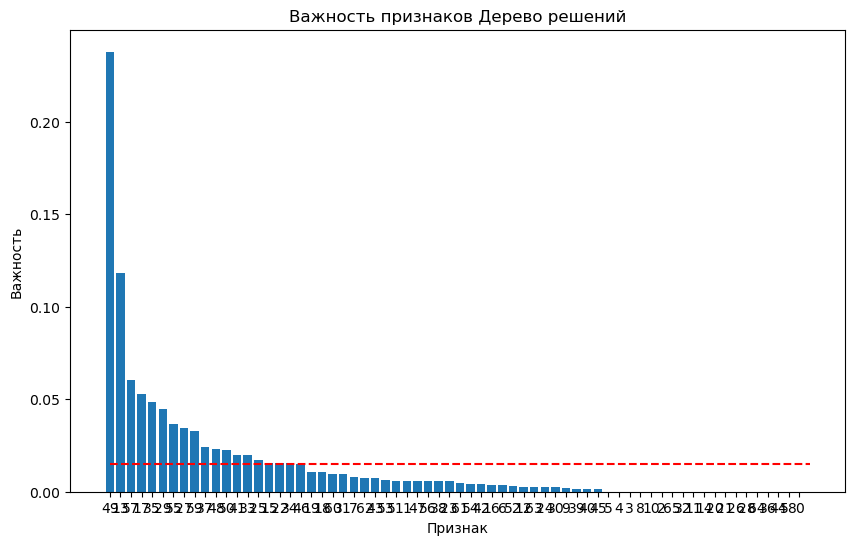

<class 'pandas.core.frame.DataFrame'>
Index: 770 entries, 38 to 708
Data columns (total 66 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Nose_x                          770 non-null    float64
 1   Nose_y                          770 non-null    float64
 2   LeftEyeInnerCorner_x            770 non-null    float64
 3   LeftEyeInnerCorner_y            770 non-null    float64
 4   LeftEye_x                       770 non-null    float64
 5   LeftEye_y                       770 non-null    float64
 6   LefEyeOuterCorner_x             770 non-null    float64
 7   LefEyeOuterCorner_y             770 non-null    float64
 8   RightEyeInnerCorner_x           770 non-null    float64
 9   RightEyeInnerCorner_y           770 non-null    float64
 10  RightEye_x                      770 non-null    float64
 11  RightEye_y                      770 non-null    float64
 12  RightEyeOuterCorner_x           770 non-

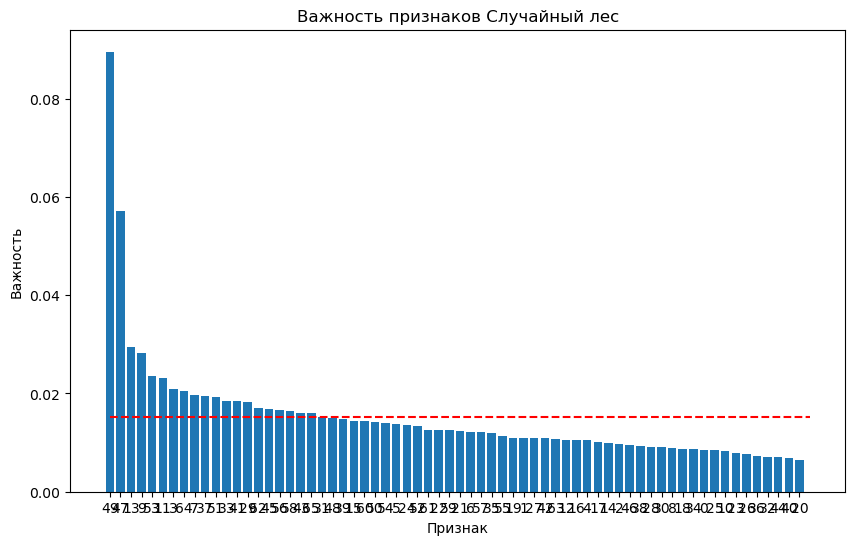

<class 'pandas.core.frame.DataFrame'>
Index: 770 entries, 38 to 708
Data columns (total 66 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Nose_x                          770 non-null    float64
 1   Nose_y                          770 non-null    float64
 2   LeftEyeInnerCorner_x            770 non-null    float64
 3   LeftEyeInnerCorner_y            770 non-null    float64
 4   LeftEye_x                       770 non-null    float64
 5   LeftEye_y                       770 non-null    float64
 6   LefEyeOuterCorner_x             770 non-null    float64
 7   LefEyeOuterCorner_y             770 non-null    float64
 8   RightEyeInnerCorner_x           770 non-null    float64
 9   RightEyeInnerCorner_y           770 non-null    float64
 10  RightEye_x                      770 non-null    float64
 11  RightEye_y                      770 non-null    float64
 12  RightEyeOuterCorner_x           770 non-

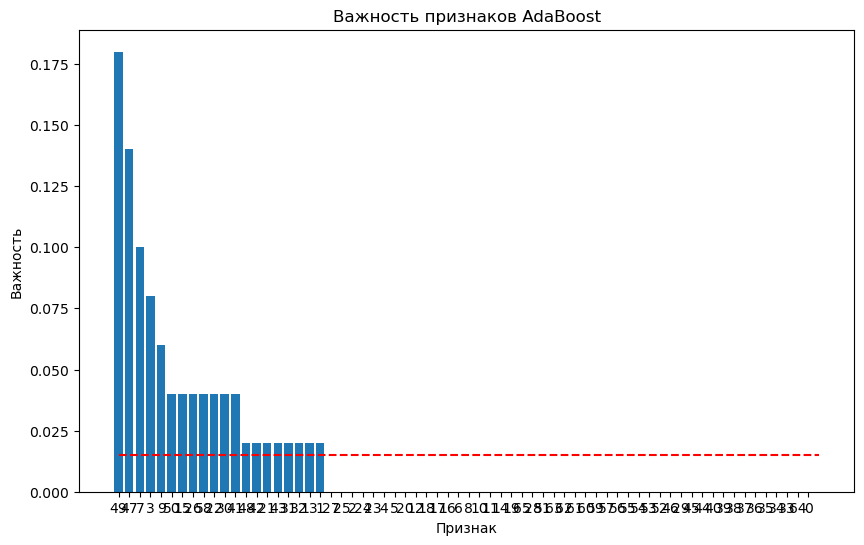

<class 'pandas.core.frame.DataFrame'>
Index: 770 entries, 38 to 708
Data columns (total 66 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Nose_x                          770 non-null    float64
 1   Nose_y                          770 non-null    float64
 2   LeftEyeInnerCorner_x            770 non-null    float64
 3   LeftEyeInnerCorner_y            770 non-null    float64
 4   LeftEye_x                       770 non-null    float64
 5   LeftEye_y                       770 non-null    float64
 6   LefEyeOuterCorner_x             770 non-null    float64
 7   LefEyeOuterCorner_y             770 non-null    float64
 8   RightEyeInnerCorner_x           770 non-null    float64
 9   RightEyeInnerCorner_y           770 non-null    float64
 10  RightEye_x                      770 non-null    float64
 11  RightEye_y                      770 non-null    float64
 12  RightEyeOuterCorner_x           770 non-

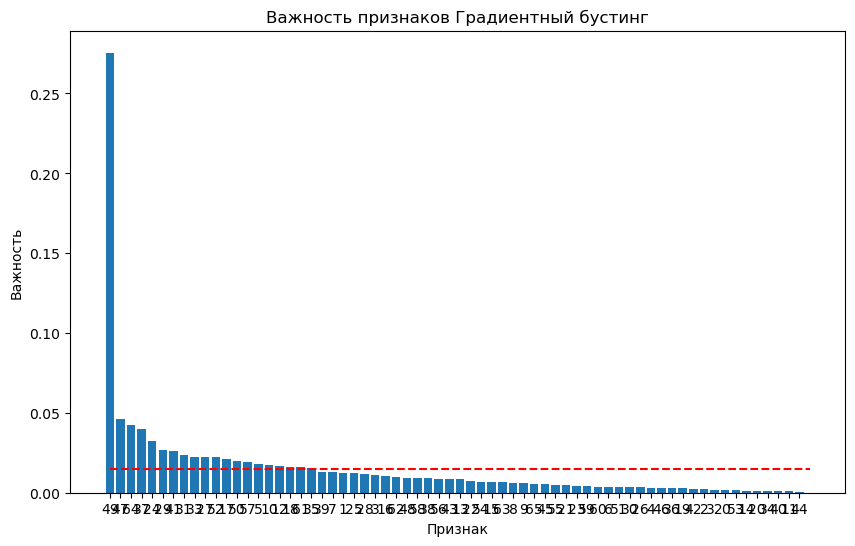

<class 'pandas.core.frame.DataFrame'>
Index: 770 entries, 38 to 708
Data columns (total 66 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Nose_x                          770 non-null    float64
 1   Nose_y                          770 non-null    float64
 2   LeftEyeInnerCorner_x            770 non-null    float64
 3   LeftEyeInnerCorner_y            770 non-null    float64
 4   LeftEye_x                       770 non-null    float64
 5   LeftEye_y                       770 non-null    float64
 6   LefEyeOuterCorner_x             770 non-null    float64
 7   LefEyeOuterCorner_y             770 non-null    float64
 8   RightEyeInnerCorner_x           770 non-null    float64
 9   RightEyeInnerCorner_y           770 non-null    float64
 10  RightEye_x                      770 non-null    float64
 11  RightEye_y                      770 non-null    float64
 12  RightEyeOuterCorner_x           770 non-

,classifier,feature_importances,Train Accuracy,Train Precision,Train Recall,Train F1,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
Логистическая регрессия,Логистическая регрессия,None,0.794805,0.801317,0.794805,0.792198,0.813472,0.830398,0.813472,0.813202
Метод опорных векторов,Метод опорных векторов,None,0.898701,0.904895,0.898701,0.895923,0.818653,0.828141,0.818653,0.814959
K-ближайших соседей,K-ближайших соседей,None,0.854545,0.857198,0.854545,0.854725,0.808290,0.812940,0.808290,0.806676
Дерево решений,Дерево решений,None,1.000000,1.000000,1.000000,1.000000,0.678756,0.689243,0.678756,0.681961
Дерево решений_fs,Дерево решений_fs,"Index(['LefEyeOuterCorner_y', 'RightEyeInnerCo...",1.000000,1.000000,1.000000,1.000000,0.689119,0.695116,0.689119,0.690363
Случайный лес,Случайный лес,None,1.000000,1.000000,1.000000,1.000000,0.844560,0.855671,0.844560,0.844821
Случайный лес_fs,Случайный лес_fs,"Index(['Nose_x', 'Nose_y', 'LeftEyeInnerCorner...",1.000000,1.000000,1.000000,1.000000,0.823834,0.833051,0.823834,0.823339
AdaBoost,AdaBoost,None,0.577922,0.572289,0.577922,0.555422,0.518135,0.504210,0.518135,0.494369
AdaBoost_fs,AdaBoost_fs,"Index(['Nose_y', 'LeftEyeInnerCorner_y', 'LefE...",0.577922,0.572289,0.577922,0.555422,0.518135,0.504210,0.518135,0.494369
Градиентный бустинг,Градиентный бустинг,None,1.000000,1.000000,1.000000,1.000000,0.818653,0.826383,0.818653,0.816773


In [532]:
# Обучение классификаторов  и отбор значимых признаков на наборе mediapipe_short
result_df = classifiers(X, Y, 'mediapipe_short')

In [533]:
display(result_df)

,classifier,feature_importances,Train Accuracy,Train Precision,Train Recall,Train F1,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
Случайный лес,Случайный лес,None,1.0,1.0,1.0,1.0,0.844560,0.855671,0.844560,0.844821
Градиентный бустинг_fs,Градиентный бустинг_fs,"Index(['Nose_y', 'LeftEyeInnerCorner_x', 'Left...",1.0,1.0,1.0,1.0,0.829016,0.841042,0.829016,0.827795
Случайный лес_fs,Случайный лес_fs,"Index(['Nose_x', 'Nose_y', 'LeftEyeInnerCorner...",1.0,1.0,1.0,1.0,0.823834,0.833051,0.823834,0.823339


,classifier,feature_importances,Train Accuracy,Train Precision,Train Recall,Train F1,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
Случайный лес,Случайный лес,None,1.0,1.0,1.0,1.0,0.844560,0.855671,0.844560,0.844821
Градиентный бустинг_fs,Градиентный бустинг_fs,"Index(['Nose_y', 'LeftEyeInnerCorner_x', 'Left...",1.0,1.0,1.0,1.0,0.829016,0.841042,0.829016,0.827795
Случайный лес_fs,Случайный лес_fs,"Index(['Nose_x', 'Nose_y', 'LeftEyeInnerCorner...",1.0,1.0,1.0,1.0,0.823834,0.833051,0.823834,0.823339


Размеры выборок:
Обучающая выборка: (770, 66)
Валидационная выборка: (193, 66)

Оптимизация Случайный лес...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Лучшие параметры для Случайный лес:
clf__max_depth: 20
clf__min_samples_leaf: 1
clf__min_samples_split: 2
clf__n_estimators: 100
poly__degree: 2

Лучший результат на обучающей выборке: 0.8312
Результат на валидационной выборке: 0.8342
Размеры выборок:
Обучающая выборка: (770, 50)
Валидационная выборка: (193, 50)

Оптимизация Градиентный бустинг...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Лучшие параметры для Градиентный бустинг:
clf__learning_rate: 0.1
clf__max_depth: 3
clf__n_estimators: 200
clf__subsample: 0.8
poly__degree: 1

Лучший результат на обучающей выборке: 0.8610
Результат на валидационной выборке: 0.8342
Размеры выборок:
Обучающая выборка: (770, 64)
Валидационная выборка: (193, 64)

Оптимизация Случайный лес...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Лучшие пар

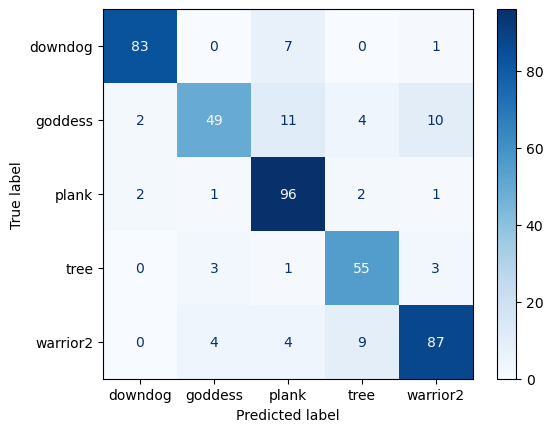

In [534]:
# Выбор оптимальной архитектуры
X_best_dataset_train, X_best_dataset_test, best_model, best_name_model, best_param = Grid_Search_CV('mediapipe_short',  X, Y, X_test, 3)

# Обучение оптимального классификатора на всем обучающем наборе и оценка его качества    
print_result(X_best_dataset_train, Y, X_best_dataset_test, Y_test, best_model, best_name_model, best_param)

In [ ]:
print(result_df.iloc[1)['feature_importances'])

In [2]:
# Загрузка модели
model = YOLO('yolo11n-pose.pt')  # load an official model

points = 17
path_train = "DATASET/TRAIN/" # Путь к датасету
path_test = "DATASET/TEST/" # Путь к датасету

In [5]:
Key_Points_YOLO = ['Nose', 'LeftEye', 'RightEye', 'LeftEar', 'RightEar', 
                   'LeftShoulder', 'RightShoulder', 'LeftElbow', 'RightElbow', 
                   'LeftWrist', 'RightWrist', 'LeftHip', 'RightHip', 
                   'LeftKnee', 'RightKnee', 'LeftAnkle', 'RightAnkle'
                  ]
classes = ['downdog', 'goddess', 'plank', 'tree', 'warrior2']

# Создаем словарь для замены
mapping = {'downdog': 0, 'goddess': 1, 'plank': 2, 'tree': 3, 'warrior2': 4}


In [6]:
# Загрузка и создание обучающего набора
data_train = pd.read_csv("dataset_train_yolo.csv")
# Заменяем значения
data_train['target'] = data_train['target'].map(mapping)

X_yolo = data_train.iloc[:, 2:-1]
Y_yolo = data_train['target']

# Загрузка и создание тестового набора
data_test = pd.read_csv("dataset_test_yolo.csv")
# Заменяем значения
data_test['target'] = data_test['target'].map(mapping)

X_test_yolo = data_test.iloc[:, 2:-1]
Y_test_yolo = data_test['target']

# Задаём гиперпараметры
params = {
    'n_estimators': 100,      # Количество деревьев
    'max_depth': 10,           # Максимальная глубина дерева
    'min_samples_split': 5,   # Минимальное число образцов для разделения узла
    'min_samples_leaf': 1,    # Минимальное число образцов в листе
    'random_state': 42,       # Для воспроизводимости
}

# Создаём модель
best_model = RandomForestClassifier(**params)

# Обучаем модель
best_model.fit(X_yolo, Y_yolo)

path = path_test
image_err = []
time_inference = 0
time_proc = 0
time_cl = 0
for dr in os.listdir(path): # Перебор папок с видами поз
    for image in os.listdir(path + "/" +dr): # Перебор файлов в каждой папке
        start_file = time.time()
        name_file = path + "/" + dr + "/" + image
        start_time = time.time()
        #data = preprocessing(name_file)
                
        # Загрузка выбранного файла
        #path ='DATASET/Train/goddess/00000137.jpg'# 'DATASET/Test/plank/00000015.jpg'             #'DATASET/Test/warrior2/00000093.jpg' 'DATASET/Train/goddess/00000137.jpg'
        temp = []
        img = cv2.imread(name_file)
        # Копирование и конвертация изображения в RGB
        imageWidth, imageHeight = img.shape[:2]
        imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Преобразование BGR модели OpenCV в RGB модель, с которой работает YOLO
        
        # Обнаружение позы            
        results = model(imgRGB)  # predict on an image 
        
        # Построение скелетной модели
        # Извлечение результатов
        for result in results[0]:
            xy = result.keypoints.xy  # x and y coordinates
            xyn = result.keypoints.xyn  # normalized
            kpts = result.keypoints.data  # x, y, visibility (if available)
        keypoints = np.array(xy[0])
        normal_keypoints = np.array(xyn[0])
        for i in range(len(normal_keypoints)):
            temp = temp + [normal_keypoints[i][0], normal_keypoints[i][1]] # Добавление ключевых точек
            
        print('Время препроцессинга: ', time.time()-start_time)
        time_proc += time.time()-start_time
        
        # Предсказание построенным классификатором класса позы по построенной скелетной модели    
        start_time = time.time()
        res = best_model.predict([temp])
        print('Время определения класса: ', time.time()-start_time) 
        time_cl += time.time()-start_time
        
        label_predict = res[0]

        # Вывод результата
        print('Эталонное название позы - ', name_file.split('/')[3]) 
        print('Предсказанное название позы - ', classes[label_predict]) 
        
        time_vis = time.time()
        time_file = time_vis - start_file

        
        if name_file.split('/')[3] != classes[label_predict]:
            image_err.append(name_file)

        # Визуализация результата
        for i, r in enumerate(results):
            # Plot results image
            im_bgr = r.plot(conf = False, kpt_radius = 7, boxes = False, masks = False)  # BGR-order numpy array
            im_rgb = Image.fromarray(im_bgr[..., ::-1])  # RGB-order PIL image
            #r.show()
            r.save(filename='ERR/results/'+dr+image)
            if name_file.split('/')[3] != classes[label_predict]:
                r.save(filename='ERR/'+dr+'_'+str(classes[label_predict])+'_'+image)
        
        
        time_inference += time_file
    
print(image_err) 
    
print(time_inference)
print(time_proc/470)
print(time_cl/470)


0: 384x640 1 person, 124.4ms
Speed: 4.1ms preprocess, 124.4ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)
Время препроцессинга:  2.060256004333496
Время определения класса:  0.017989397048950195
Эталонное название позы -  downdog
Предсказанное название позы -  downdog

0: 384x640 1 person, 56.8ms
Speed: 3.0ms preprocess, 56.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Время препроцессинга:  0.09711050987243652
Время определения класса:  0.014136791229248047
Эталонное название позы -  downdog
Предсказанное название позы -  downdog

0: 480x640 1 person, 83.9ms
Speed: 2.8ms preprocess, 83.9ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Время препроцессинга:  0.13839197158813477
Время определения класса:  0.010777473449707031
Эталонное название позы -  downdog
Предсказанное название позы -  downdog

0: 448x640 1 person, 77.8ms
Speed: 2.5ms preprocess, 77.8ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)
В